# Monte Carlo Convergence and Volatility Analysis
This notebook visualizes the outputs of the `MonteCarloPricingEngine`. 
Our goal is to demonstrate two key financial engineering concepts:
1. **Log-Normal Distribution:** The terminal prices of an asset following Geometric Brownian Motion must be log-normally distributed.
2. **The Law of Large Numbers:** As the number of simulated paths $N$ approaches infinity, the Monte Carlo estimate converges to the theoretical true price of the option.

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Adjust path to import from the models directory
sys.path.append(os.path.abspath('..'))
from models.engine import MonteCarloPricingEngine

# Set plotting style for professional presentation
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Define Option Parameters
S0 = 100.0     # Initial stock price
K = 105.0      # Strike price
T = 1.0        # Time to maturity (1 year)
r = 0.05       # Risk-free rate (5%)
sigma = 0.20   # Annual volatility (20%)

# Instantiate the engine with 50,000 simulations for a smooth distribution
engine = MonteCarloPricingEngine(S0=S0, K=K, T=T, r=r, sigma=sigma, num_simulations=50000)

# Calculate price and retrieve paths
call_price, paths = engine.price_european_call()
terminal_prices = paths[-1]

print(f"Estimated European Call Price: €{call_price:.4f}")

Estimated European Call Price: €8.0863


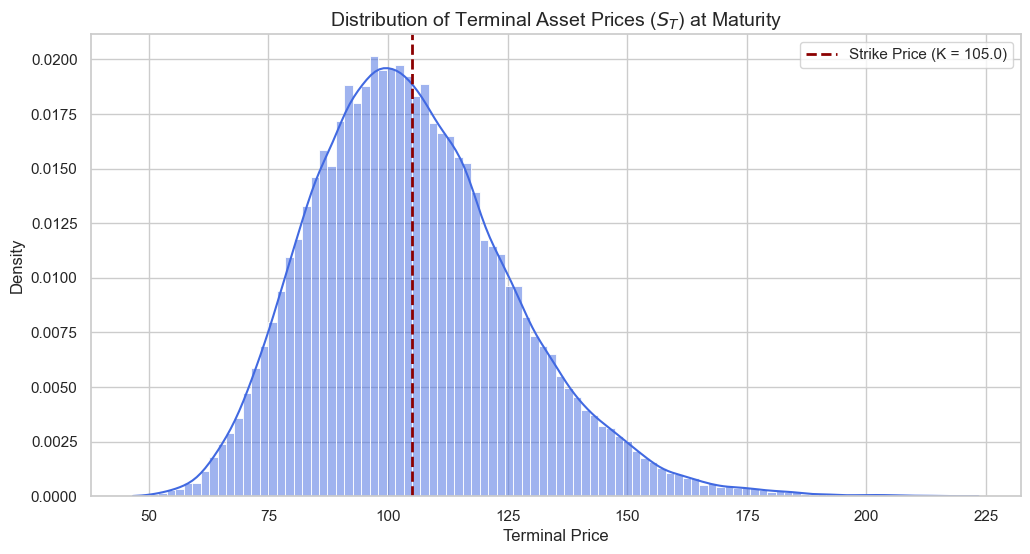

In [3]:
plt.figure(figsize=(12, 6))
sns.histplot(terminal_prices, bins=100, kde=True, color='royalblue', stat='density')

# Add a vertical line for the Strike Price
plt.axvline(K, color='darkred', linestyle='--', linewidth=2, label=f'Strike Price (K = {K})')

plt.title('Distribution of Terminal Asset Prices ($S_T$) at Maturity', fontsize=14)
plt.xlabel('Terminal Price', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.show()

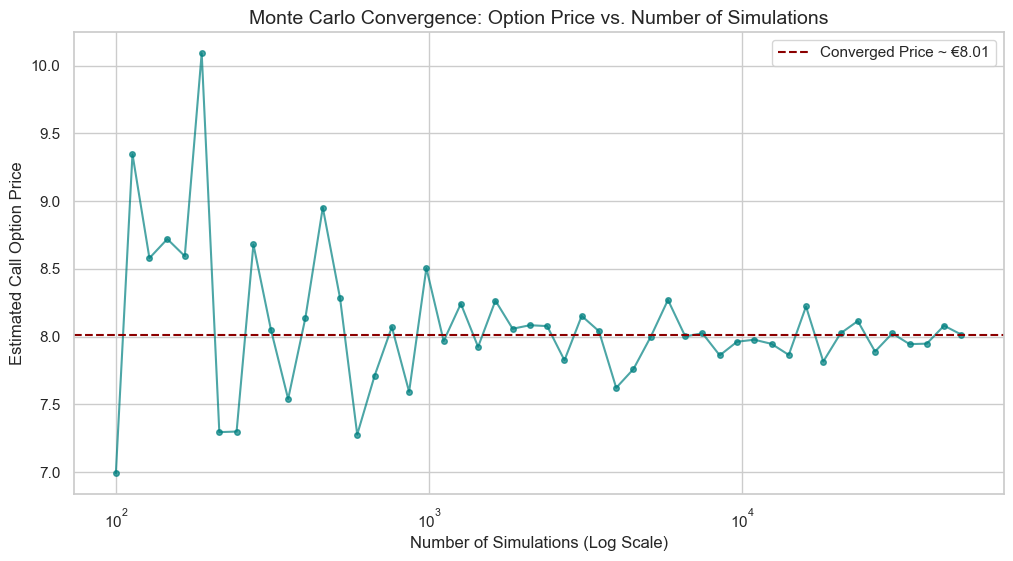

In [4]:
sim_counts = np.logspace(2, 4.7, 50).astype(int) # Array from 100 to ~50,000 simulations
prices = []

for n in sim_counts:
    temp_engine = MonteCarloPricingEngine(S0=S0, K=K, T=T, r=r, sigma=sigma, num_simulations=n)
    price, _ = temp_engine.price_european_call()
    prices.append(price)

plt.figure(figsize=(12, 6))
plt.plot(sim_counts, prices, marker='o', markersize=4, linestyle='-', color='teal', alpha=0.7)
plt.axhline(prices[-1], color='darkred', linestyle='--', label=f'Converged Price ~ €{prices[-1]:.2f}')

plt.xscale('log')
plt.title('Monte Carlo Convergence: Option Price vs. Number of Simulations', fontsize=14)
plt.xlabel('Number of Simulations (Log Scale)', fontsize=12)
plt.ylabel('Estimated Call Option Price', fontsize=12)
plt.legend()
plt.show()